# Часть 1. Проверка гипотезы в Python и составление аналитической записки

Загружены предварительно мною обработанные в SQL данные пользователей из Москвы и Санкт-Петербурга с суммой часов их активности из файла yandex_knigi_data.csv.

Проверены наличие дубликатов в идентификаторах пользователей. Сравнены размеры групп, их статистики и распределение.

Гипотеза выглядит следующим образом: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Докажем это статистически, используя одностороннюю проверку гипотезы с двумя выборками.

Нулевая гипотеза $H_0: \mu_{\text{СПб}} \leq \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге не больше, чем в Москве.

Альтернативная гипотеза $H_1: \mu_{\text{СПб}} > \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

По результатам анализа данных будет составлена аналитическая записка, в которой будет описано:

Выбранный тип t-теста и уровень статистической значимости.

Результат теста, или p-value.

Вывод на основе полученного p-value, то есть интерпретацию результатов.

Возможные причины, объясняющие полученные результаты.

## Проверка гипотезы об активности пользователей в зависимости от города.

- Автор:Сотнезов Виталий Александрович
- Дата:19.02.2026

## Цели и задачи проекта

* Проверка гипотезы, что пользователи из города Санкт-Петербург проявляют больше активности, чем пользователи из Москвы.

## Описание данных

Заранее подготовленный файл yandex_knigi_data.csv представляет из себя df, состоящий из 3 столбцов данных. 
* city - Город (только Москва и Санкт-Петербург)
* puid — уникальный идентификатор пользователя.
* hours - Суммарное время, проведенное в приложении.

## Содержимое проекта



     5  1. Загрузка данных и знакомство с ними
     6  2. Проверка гипотезы в Python
     7  3. Аналитическая записка
            Часть 2.
     8  1. Цели исследования.
     9  2. Загрузка данных и проверка их целостности.
     10 3. Оценка корректности проведения теста.
     11 4. Оценка результатов A/B-тестирования.

## 1. Загрузка данных и знакомство с ними

Загружаю данные пользователей из Москвы и Санкт-Петербурга c их активностью (суммой часов чтения и прослушивания) из файла `/datasets/yandex_knigi_data.csv`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.proportion import proportions_ztest
import numpy as np

In [2]:
df = pd.read_csv('https://code.s3.yandex.net/datasets/yandex_knigi_data.csv')

In [3]:
df.info()
df.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  8784 non-null   int64  
 1   city        8784 non-null   object 
 2   puid        8784 non-null   int64  
 3   hours       8784 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 274.6+ KB


,Unnamed: 0,city,puid,hours
0,0,Москва,9668,26.167776
1,1,Москва,16598,82.111217
2,2,Москва,80401,4.656906


## 2. Проверка гипотезы в Python

Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

 Проверяем суммарное время, проведенное в приложении по городам. 

In [4]:
city_hours = df.groupby('city')['hours'].sum()#.reset_index()
display(round(city_hours,1))

city
Москва             67832.7
Санкт-Петербург    29561.4
Name: hours, dtype: float64

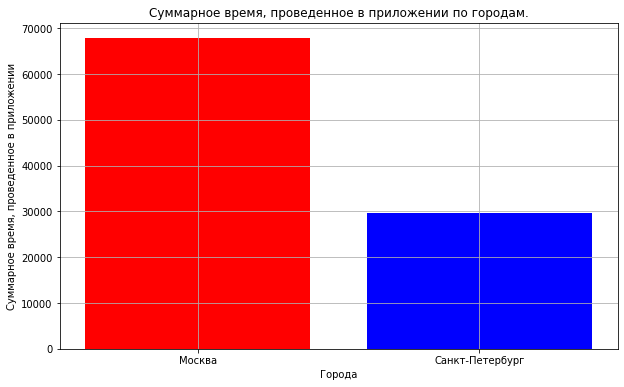

In [5]:
plt.figure(figsize=(10, 6))

group1=['Москва','Санкт-Петербург']
plt.bar(group1, city_hours, color=['red', 'blue'])
plt.xlabel('Города')
plt.ylabel('Суммарное время, проведенное в приложении')
plt.title('Суммарное время, проведенное в приложении по городам.')
plt.grid()
plt.show()

 Проверяем количество уникальных пользователей в зависимости от города.

In [6]:
city_users = df.groupby('city')['puid'].nunique()#.reset_index()
display(city_users.head(3))

city
Москва             6234
Санкт-Петербург    2550
Name: puid, dtype: int64

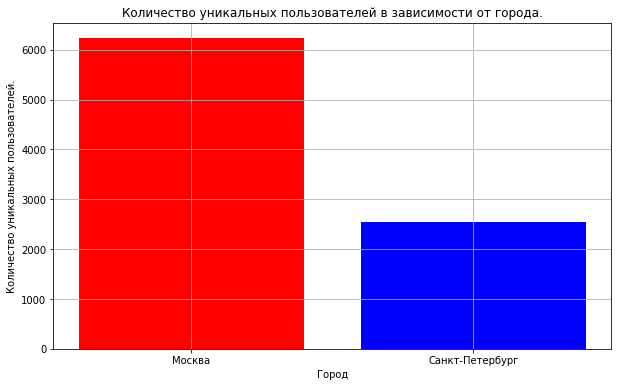

In [7]:
plt.figure(figsize=(10, 6))

group1=['Москва','Санкт-Петербург']
plt.bar(group1, city_users, color=['red', 'blue'])
plt.xlabel('Город')
plt.ylabel('Количество уникальных пользователей.')
plt.title('Количество уникальных пользователей в зависимости от города.')
plt.grid()
plt.show()

Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

In [8]:
moscow_puid = df[df['city'] == 'Москва']['puid']
spb_puid = df[df['city'] == 'Санкт-Петербург']['puid']

intersection = list(set(moscow_puid) & set(spb_puid))
print("Пользователи в обеих группах:", intersection)
display(f'Количество пользователей в Москве. {moscow_puid.shape[0]}')
display(f'Количество пользователей в СПБ. {spb_puid.shape[0]}')

Пользователи в обеих группах: [439054848, 98068993, 84978689, 331188228, 59679749, 790564870, 40698887, 162106378, 1078819852, 1684058125, 1130000018954257, 959563282, 571554323, 1358054932, 313990163, 1778617878, 1210363415, 1316543509, 649885721, 1183963675, 1395494429, 1314529823, 1145886241, 1593760291, 1725564965, 24138278, 520518182, 363351088, 108083761, 570189363, 584447544, 860187201, 309104707, 550835780, 441112643, 1977784899, 1406501962, 528250442, 103543372, 1616171597, 589188176, 989693522, 1958805587, 401065555, 1557916755, 429727314, 1130000028554332, 488154206, 1965288031, 10597984, 9979490, 301108324, 1607495785, 767485035, 453988975, 912829040, 955554416, 1672056947, 819309176, 10815097, 196683896, 1076879993, 1974615673, 531369086, 1011254911, 555866239, 258809476, 66998918, 360290950, 1085783174, 236601993, 359740041, 998045836, 888840333, 2019864206, 1109631631, 1713008273, 317826707, 1236880533, 46837910, 1166679702, 137198745, 1891219106, 987817124, 1735154341, 

'Количество пользователей в Москве. 6234'

'Количество пользователей в СПБ. 2550'

In [9]:
moscow_puid_filtered = moscow_puid[~moscow_puid.isin(intersection)]
spb_puid_filtered = spb_puid[~spb_puid.isin(intersection)]
display(f'Количество неповторяющихся пользователей в Москве. {moscow_puid_filtered.shape[0]}')
display(f'Количество неповторяющихся пользователей в СПБ. {spb_puid_filtered.shape[0]}')

'Количество неповторяющихся пользователей в Москве. 5990'

'Количество неповторяющихся пользователей в СПБ. 2306'

In [10]:
moscow_filtered_hours = df[df['city'] == 'Москва']['hours']
spb_filtered_hours = df[df['city'] == 'Санкт-Петербург']['hours']

In [11]:
stat_moscow, p_moscow = stats.shapiro(moscow_puid_filtered)
stat_spb, p_spb = stats.shapiro(spb_puid_filtered)

print(f"Москва: p-value = {p_moscow}")
print(f"Санкт-Петербург: p-value = {p_spb}")

Москва: p-value = 0.0
Санкт-Петербург: p-value = 0.0


/opt/conda/lib/python3.9/site-packages/scipy/stats/_morestats.py:1800: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


Распределение не соответствует нормальному, применяем тест Манна–Уитни. 


In [12]:
alpha = 0.05

In [13]:
u_stat, p_value = stats.mannwhitneyu(moscow_filtered_hours, spb_filtered_hours, alternative='greater')

print(f"U-статистика: {u_stat}")
print(f"p-value: {p_value}")

U-статистика: 7803084.0
p-value: 0.9109420539159508


In [14]:
if p_value >= alpha:
    print("Статистически значимых различий нет.")
else:
    print("Разница статистически значима.")

Статистически значимых различий нет.


## 3. Аналитическая записка
По результатам анализа данных будет составлена аналитическая записка, в которой будет описано:

- Выбранный тип t-теста и уровень статистической значимости.

- Результат теста, или p-value.

- Вывод на основе полученного p-value, то есть интерпретацию результатов.

- Одну или две возможные причины, объясняющие полученные результаты.



*  Распределения активности в обеих группах не являются нормальными. Вместо t-теста был использован непараметрический тест Манна–Уитни (U-тест), который не требует нормальности распределения
*  p-value = 0.9109420539159508
* На основе полученного результата при alpha = 0.05 было выявлено отсутствие статистически значимых различий.
* На основе теста могу предположить, что независимо от количества пользователей по городам (Москва — 6234, Санкт-Петербург — 2550), данное приложение пользуется одинаковой популярностью в обоих городах. 

# Часть 2. Анализ результатов A/B-тестирования

Проанализируем другие данные. 
Введение.К вам обратились представители интернет-магазина BitMotion Kit, в котором продаются геймифицированные товары для тех, кто ведёт здоровый образ жизни. У него есть своя целевая аудитория, даже появились хиты продаж: эспандер со счётчиком и напоминанием, так и подстольный велотренажёр с Bluetooth.

В будущем компания хочет расширить ассортимент товаров. Но перед этим нужно решить одну проблему. Интерфейс онлайн-магазина слишком сложен для пользователей — об этом говорят отзывы.

Чтобы привлечь новых клиентов и увеличить число продаж, владельцы магазина разработали новую версию сайта и протестировали его на части пользователей. По задумке, это решение доказуемо повысит количество пользователей, которые совершат покупку.

Ваша задача — провести оценку результатов A/B-теста. В вашем распоряжении:

* данные о действиях пользователей и распределении их на группы,

* техническое задание.

Оценю корректность проведения теста и проанализирую его результаты.

## 1. Цели исследования.



* Проверить гипотезу о том, что изменение дизайна сайта повысит количество пользователей, которые совершат покупку.

## 2. Загрузка данных и проверка их целостности.


In [15]:
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)

In [16]:
participants.info()
participants.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB


,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


In [17]:
events.info()
events.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  object        
 1   event_dt    787286 non-null  datetime64[ns]
 2   event_name  787286 non-null  object        
 3   details     249022 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 24.0+ MB


,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN


## 3. Оценка корректности проведения теста:

   3\.1 Выделяем пользователей, участвующих в тесте:

   - соответствие требованиям технического задания,

   - равномерность распределения пользователей по группам теста,

   - отсутствие пересечений с конкурирующим тестом (нет пользователей, участвующих одновременно в двух тестовых группах).

In [18]:
# Группировка по тэсту
ab_test_participants = participants[participants['ab_test']=='interface_eu_test']
display()

In [19]:
# Группировка по группам
group_a = participants[participants['group']=='A']
group_b = participants[participants['group']=='B']

In [20]:
gr_ab_test_participants = ab_test_participants.groupby('group')['user_id'].nunique()

unique_users_a = gr_ab_test_participants.loc['A'] #5383
unique_users_b = gr_ab_test_participants.loc['B'] #5467

group_p = ((unique_users_b - unique_users_a) / unique_users_a) * 100
display(f"Процентная разница в количестве пользователей в группах A и B составляет {round(group_p,2)}%")
#display(unique_users_a, unique_users_b)

'Процентная разница в количестве пользователей в группах A и B составляет 1.56%'

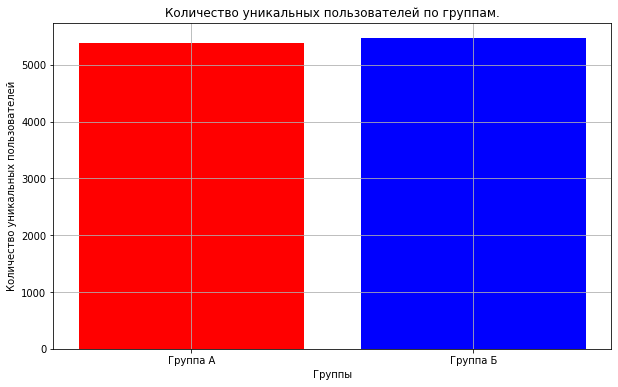

group
A    5383
B    5467
Name: user_id, dtype: int64

In [21]:

plt.figure(figsize=(10, 6))

group2 = ['Группа А','Группа Б']
plt.bar(group2, gr_ab_test_participants, color=['red', 'blue'])
plt.xlabel('Группы')
plt.ylabel('Количество уникальных пользователей')
plt.title('Количество уникальных пользователей по группам.')
plt.grid()
plt.show()
display(gr_ab_test_participants)

In [22]:
intersection = list(set(group_a) & set(group_b))
print("Пользователи в обеих группах:", intersection)

Пользователи в обеих группах: ['user_id', 'group', 'device', 'ab_test']


In [23]:
# interface_eu_test пользователи 
interface_eu_participants = participants[participants['ab_test'] == 'interface_eu_test']['user_id']

# recommender_system_test пользователи
recommender_participants = participants[participants['ab_test'] == 'recommender_system_test']['user_id']
# пересечения
intersection_test = set(interface_eu_participants) & set(recommender_participants)
print("Пользователи участвующие в обоих тестах:", intersection_test)

Пользователи участвующие в обоих тестах: {'3F775ABC71333988', 'A8C1429C2249A1C3', '0C2E77C6A381704A', 'D9128C07E09FF452', 'D2D8E67B7D0DE2D2', 'C41BBCA9DACE544D', 'AEE24B6142A3C431', 'FC3F3E4DA7C85F88', '7875B71ED824F8F2', 'EA8341F38EFFE04C', '8F98834C531143DA', '3A5B11DD76C2CA65', '67AB39E76836E176', 'C286A270CFB9925D', '507ADD5337970C14', 'C9E32DE296F68008', '04F2CF340B4F3822', '4B5225B3DCB853CE', '5461DD0AF191F581', '80055F949A01DDAD', 'C1FFA9A2B049B203', '2DF9E85A613E0DD0', '051D59BC38C3B3AA', 'DF72BA6A526F714F', '54633A9BB233F1E6', '9A5549A4A85FCF06', '10863662C3B5AB49', '0EA9AB1C2A159C77', '1B52830A832D33F5', '2A2A3F0E002F81B5', 'A4312FFD172A4998', '96749D41A2185B46', 'A412E4B7C71C0D94', 'D8DA1D568FCF46ED', '198FEF39910DCF76', '34A2E022930DFCA3', '3B62EE83708770A5', 'DD9DDDB53DA30E40', '2F52D15FF20EE730', '8FBAEB717ABA3930', '3382B624CF985A13', 'DC41AFF8213BE01A', 'B997F98ED3AA6104', '5ECF8AD51FC8062E', 'B60B4563ADC259E3', '6B72CFAE1935C789', 'C8BDDF5639850737', '8FF8F87305BB9A7D'

In [24]:
participants = participants[(participants['ab_test'] == 'interface_eu_test') &(~participants['user_id'].isin(intersection_test))]

3\.2 Анализируем данные о пользовательской активности по таблице `ab_test_events`:

- оставленны только события, связанные с участвующими в изучаемом тесте пользователями;

In [25]:
# объединяем df
merged_df = pd.merge(participants, events, on='user_id', how='left')

In [26]:
ab_merged_df = merged_df[(merged_df['event_name'] == 'registration') | (merged_df['event_name'] == 'purchase')]
display(ab_merged_df.head(5))

,user_id,group,ab_test,device,event_dt,event_name,details
0,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:31,registration,-2.38
11,001E72F50D1C48FA,A,interface_eu_test,Mac,2020-12-17 15:44:05,registration,-3.61
18,002412F1EB3F6E38,B,interface_eu_test,Mac,2020-12-09 09:36:50,registration,-0.48
26,002540BE89C930FB,B,interface_eu_test,Android,2020-12-08 18:06:07,registration,-2.38
35,0031F1B5E9FBF708,A,interface_eu_test,Android,2020-12-14 00:47:10,registration,-2.26


In [27]:
duplicates = ab_merged_df.duplicated()
print(duplicates.sum())  # количество дубликатов

586


In [28]:
ab_merged_df = ab_merged_df.drop_duplicates()

In [29]:
duplicates = ab_merged_df.duplicated()
print(duplicates.sum())

0


- определяем горизонт анализа: рассчитываем время (лайфтайм) совершения события пользователем после регистрации и оставляем только те события, которые были выполнены в течение первых семи дней с момента регистрации;

In [30]:


# Выделяем только события регистрации для расчёта даты первой регистрации
registrations = ab_merged_df[ab_merged_df['event_name'] == 'registration']

# Находим первую дату регистрации для каждого пользователя
first_registration = registrations.groupby('user_id')['event_dt'].min().reset_index()

In [31]:
# Присоединяем дату первой регистрации к ab_merged_df
ab_merged_df = ab_merged_df.merge(first_registration, on='user_id', how='left', suffixes=('', '_first'))

# Преобразуем столбец event_dt (если он ещё не datetime)
ab_merged_df['event_dt'] = pd.to_datetime(ab_merged_df['event_dt'], errors='coerce')

# Преобразуем столбец event_dt_first (если он ещё не datetime)
ab_merged_df['event_dt_first'] = pd.to_datetime(ab_merged_df['event_dt_first'], errors='coerce')

# Вычисляем разницу в днях
ab_merged_df['lifetime_days'] = (ab_merged_df['event_dt'] - ab_merged_df['event_dt_first']).dt.days

In [32]:
# Фильтруем события: оставляем только с lifetime_days < 7
ab_merged_df_7days = ab_merged_df[ab_merged_df['lifetime_days'] < 7]

In [33]:
ab_merged_df_7days.head()

,user_id,group,ab_test,device,event_dt,event_name,details,event_dt_first,lifetime_days
0,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:31,registration,-2.38,2020-12-07 04:37:31,0
1,001E72F50D1C48FA,A,interface_eu_test,Mac,2020-12-17 15:44:05,registration,-3.61,2020-12-17 15:44:05,0
2,002412F1EB3F6E38,B,interface_eu_test,Mac,2020-12-09 09:36:50,registration,-0.48,2020-12-09 09:36:50,0
3,002540BE89C930FB,B,interface_eu_test,Android,2020-12-08 18:06:07,registration,-2.38,2020-12-08 18:06:07,0
4,0031F1B5E9FBF708,A,interface_eu_test,Android,2020-12-14 00:47:10,registration,-2.26,2020-12-14 00:47:10,0


In [34]:
ab_merged_df_7days.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 15800 entries, 0 to 18863
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   user_id         15800 non-null  object        
 1   group           15800 non-null  object        
 2   ab_test         15800 non-null  object        
 3   device          15800 non-null  object        
 4   event_dt        15800 non-null  datetime64[ns]
 5   event_name      15800 non-null  object        
 6   details         15800 non-null  object        
 7   event_dt_first  15800 non-null  datetime64[ns]
 8   lifetime_days   15800 non-null  int64         
dtypes: datetime64[ns](2), int64(1), object(6)
memory usage: 1.2+ MB


Оцениваем достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры:

- базовый показатель конверсии — 30%,

- мощность теста — 80%,

- достоверность теста — 95%.

In [35]:
# Задаем параметры
alpha = 0.05  # уровень значимости
beta = 0.2  # ошибка второго рода, часто 1 - мощность
power = 1 - beta  # мощность теста
p = 0.3 # Базовый уровень доли
mde = 0.03  # минимально значимое изменение = 3%
effect_size = proportion_effectsize(p, p + mde)

# инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# расчет размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size, power=power, alpha=alpha, ratio=1
)  # равномерное распределение выборок

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 3761


- рассчитываем для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей.

In [36]:
purchases = ab_merged_df_7days[ab_merged_df_7days['event_name'] == 'purchase']

purchase_count_by_group = purchases.groupby('group')['user_id'].nunique()
print("Количество посетителей, сделавших покупку, по группам:")
print(purchase_count_by_group)

Количество посетителей, сделавших покупку, по группам:
group
A    1377
B    1480
Name: user_id, dtype: int64


In [37]:
total_visitors_by_group = ab_merged_df_7days.groupby('group')['user_id'].nunique()
print("Общее количество уникальных посетителей по группам:")
print(total_visitors_by_group)

Общее количество уникальных посетителей по группам:
group
A    4952
B    5011
Name: user_id, dtype: int64


In [38]:
purchase_a, purchase_b = 2139, 1791
total_a, total_b = 7805, 6279

# конверсия
cr_a = (purchase_a / total_a) * 100
cr_b = (purchase_b / total_b) * 100

# прирост
con = ((cr_b - cr_a) / cr_a) * 100

# Вывод результатов
print(f"Конверсия группы A: {round(cr_a,2)}%")
print(f"Конверсия группы B: {round(cr_b,2)}%")
print(f"Прирост конверсии (B vs A): {round(con,2)}%")

Конверсия группы A: 27.41%
Конверсия группы B: 28.52%
Прирост конверсии (B vs A): 4.08%


Предварительный вывод: количество посетителей, сделавших покупку, в контрольной группе A больше, чем в тестовой, как и общее количество пользователей. 

Конверсия группы A: 27.41% 

Конверсия группы B: 28.52%

Конверсия в покупку между тестовыми группами увеличилась на 4.08% в пользу группы B.

## 4.  Оценка результатов A/B-тестирования:

- проверяем изменение конверсии подходящим статистическим тестом, учитывая все этапы проверки гипотез.

Рассматриваются следующие гипотезы:
* Нулевая гипотеза (H₀): конверсия в покупку между экспериментальной и контрольной группой не отличается (не изменилась).
* Альтернативная гипотеза (H₁): конверсия в покупку между экспериментальной и контрольной группой в экспериментальной группе выше, чем в контрольной группе.

In [39]:
# # Группа А
# n_a = ab_merged_df_7days[ab_merged_df_7days['group'] == 'A'].shape[0]
# m_a = ab_merged_df_7days[(ab_merged_df_7days['group'] == 'A') & (ab_merged_df_7days['event_name'] == 'purchase')].shape[0]  # число конверсий

# # Группа B
# n_b = ab_merged_df_7days[ab_merged_df_7days['group'] == 'B'].shape[0]
# m_b = ab_merged_df_7days[(ab_merged_df_7days['group'] == 'B') & (ab_merged_df_7days['event_name'] == 'purchase')].shape[0]  # число конверсий

# # 3. Z-тест
# stat, p_value = proportions_ztest(
#     count=[m_a, m_b],
#     nobs=[n_a, n_b],
#    alternative='smaller'
# )
stat, p_value = proportions_ztest(
    count=[purchase_b, purchase_a],
    nobs=[total_b, total_a],
    alternative='larger'
)

# Выводим результаты
print(f"Z-статистика: {stat:.4f}")
print(f"P-значение: {p_value:.4f}")

Z-статистика: 1.4705
P-значение: 0.0707


In [40]:
print(f'p-value = {p_value:.3f}')

# Вывод
alpha = 0.05
if p_value > alpha:
    print("Статистически значимых различий нет.")
else:
    print("Разница статистически значима.")

p-value = 0.071
Статистически значимых различий нет.


- выводы по проведённой оценке результатов A/B-тестирования. Что можно сказать про результаты A/B-тестирования? Был ли достигнут ожидаемый эффект в изменении конверсии?

* Различия в конверсии между группой A (текущая версия сайта) и группой B (новая версия сайта) не имеют статистически значимых различий;
* Высока вероятность того, что наблюдаемые различия вызваны случайностью.

Рекомендация по внедрению: Новая версия не показала увеличение конверсии в покупку, возможно, увеличение выборки может повлиять на результат. Я считаю, что стоит проверить другие гипотезы, чтобы понять, на что могла повлиять новая версия сайта.